# Exploratory Data Analysis (EDA)
---

In [79]:
import pandas as pd
import matplotlib.pyplot as plt

import scipy.stats as stats

In [80]:
data = pd.read_csv('../data/processed/working_dataset.csv')
data

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0
...,...,...,...,...,...,...,...,...,...
99995,Female,80.0,0,0,No Info,27.32,6.2,90,0
99996,Female,2.0,0,0,No Info,17.37,6.5,100,0
99997,Male,66.0,0,0,former,27.83,5.7,155,0
99998,Female,24.0,0,0,never,35.42,4.0,100,0


### Gender analysis
----

In [81]:
data['gender'].value_counts()

gender
Female    58552
Male      41430
Other        18
Name: count, dtype: int64

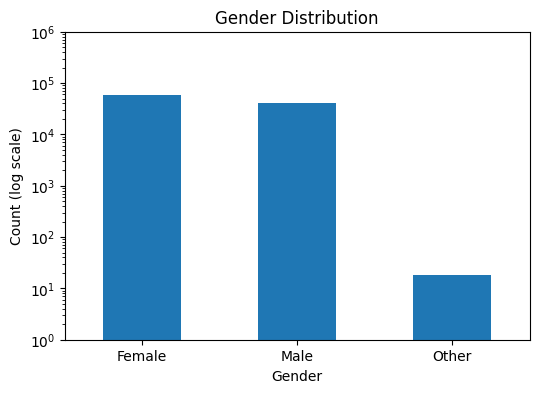

In [82]:
# Count the number of records for each gender category
gender_counts = data['gender'].value_counts()

# Create a new figure with a fixed size
plt.figure(figsize=(6, 4))

# Plot the gender counts as a bar chart
gender_counts.plot(kind='bar')

# Apply logarithmic scale to the Y-axis.
# This is useful because the "Other" category has much fewer observations
# compared to "Female" and "Male".
plt.yscale('log')

# Set the Y-axis range from 1 to 1,000,000.
# Note: 10**6 = 1,000,000
plt.ylim(1, 10**6)

# Add chart title and axis labels
plt.title('Gender Distribution')
plt.xlabel('Gender')
plt.ylabel('Count (log scale)')

# Keep the X-axis labels horizontal
plt.xticks(rotation=0)

# Save the figure
plt.savefig('../reports/figures/gender_distribution.png',
            dpi=300,
            bbox_inches='tight')

# Display the chart
plt.show()

### Age analysis
---

In [83]:
# Descriptive statistics for the age feature
data['age'].describe()

count    100000.000000
mean         41.885856
std          22.516840
min           0.080000
25%          24.000000
50%          43.000000
75%          60.000000
max          80.000000
Name: age, dtype: float64

- **Mean age:** Approximately **41 years**.
- **Age range:** Patients aged **0 to 80 years**.

- **25% (Q1):** First quartile (25% of the observations are below this value).
- **50% (Median):** Second quartile (50% of the observations are below this value).
- **75% (Q3):** Third quartile (75% of the observations are below this value).

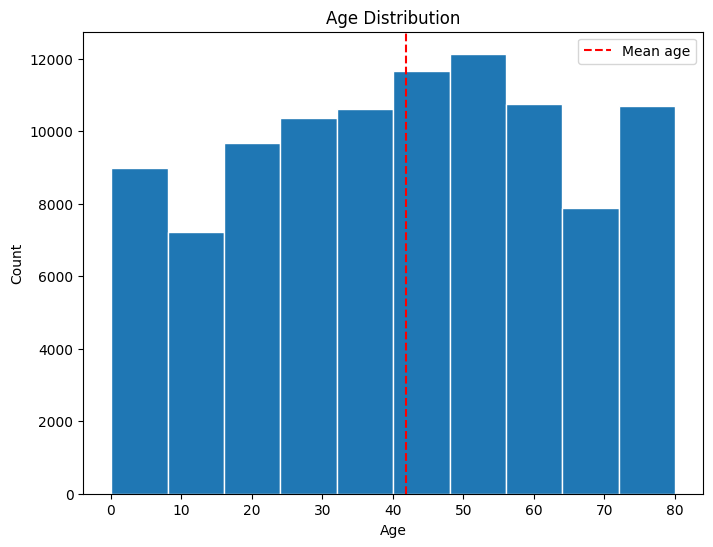

In [84]:
# Create a new figure with a fixed size
plt.figure(figsize=(8, 6))

# Plot the age distribution as a histogram
plt.hist(data['age'], edgecolor='white')

# Calculate the mean age
mean_age = data['age'].mean()

# Add a vertical dashed line showing the mean age
plt.axvline(mean_age, c='r', linestyle='--', label='Mean age')

# Add axis labels
plt.xlabel('Age')
plt.ylabel('Count')

# Display the legend
plt.legend()

# Add chart title
plt.title('Age Distribution')

plt.savefig('../reports/figures/age_distribution.png',
            dpi=300,
            bbox_inches='tight')

# Display the chart
plt.show()

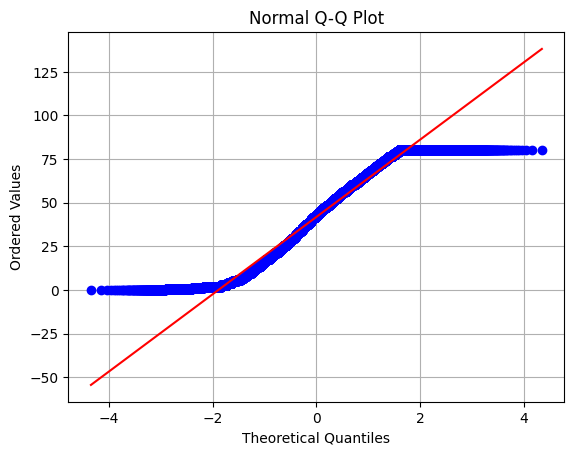

In [85]:
# Extract the age feature
age = data['age']

# Create a Q-Q (Quantile-Quantile) plot to assess whether
# the age distribution follows a normal distribution.
stats.probplot(age, dist="norm", plot=plt)

# Add chart title and axis labels
plt.title('Normal Q-Q Plot')
plt.xlabel('Theoretical Quantiles')
plt.ylabel('Ordered Values')

# Display grid lines for easier interpretation
plt.grid(True)

plt.savefig('../reports/figures/age_q_q_plot.png',
            dpi=300,
            bbox_inches='tight')

# Display the plot
plt.show()

### Conclusions

- The age feature does not follow a normal distribution.
- The central observations approximately follow the theoretical normal line.
- Significant deviations are observed in both tails of the distribution.
- The upper tail is truncated because the maximum recorded age is 80 years.
- Therefore, the age feature cannot be considered normally distributed.

### Hypertension analysisi
---

In [86]:
data['hypertension'].value_counts()

hypertension
0    92515
1     7485
Name: count, dtype: int64

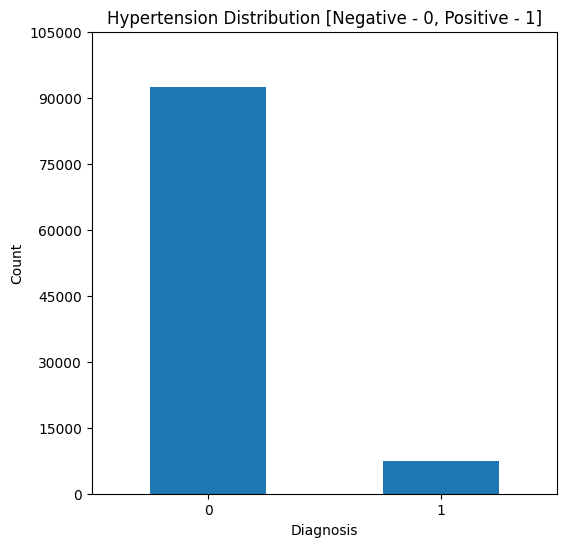

In [87]:

hypertension_counts = data['hypertension'].value_counts()

# Create a new figure with a fixed size
plt.figure(figsize=(6, 6))

# Plot the gender counts as a bar chart
hypertension_counts.plot(kind='bar')


# Add chart title and axis labels
plt.title('Hypertension Distribution [Negative - 0, Positive - 1]')
plt.xlabel('Diagnosis')
plt.ylabel('Count')

# Keep the X-axis labels horizontal
plt.xticks(rotation=0)
plt.yticks(range(0, 110000, 15000))

# Save the figure
plt.savefig('../reports/figures/hypertension_distribution.png',
            dpi=300,
            bbox_inches='tight')

# Display the chart
plt.show()

### Heart disease analysis

In [89]:
data['heart_disease'].value_counts()

heart_disease
0    96058
1     3942
Name: count, dtype: int64

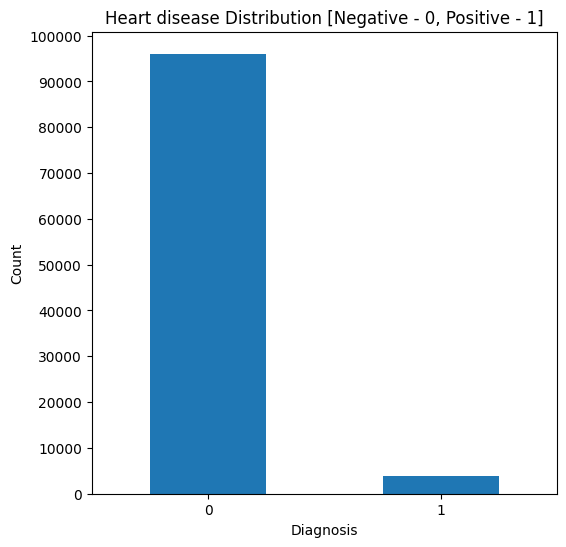

In [91]:
heart_disease_counts = data['heart_disease'].value_counts()

# Create a new figure with a fixed size
plt.figure(figsize=(6, 6))

# Plot the gender counts as a bar chart
heart_disease_counts.plot(kind='bar')

# Add chart title and axis labels
plt.title('Heart disease Distribution [Negative - 0, Positive - 1]')
plt.xlabel('Diagnosis')
plt.ylabel('Count')

# Keep the X-axis labels horizontal
plt.xticks(rotation=0)
plt.yticks(range(0, 110000, 10000))

# Save the figure
plt.savefig('../reports/figures/heart_disease_distribution.png',
            dpi=300,
            bbox_inches='tight')

# Display the chart
plt.show()

### Smoking history analysis

In [93]:
data['smoking_history'].value_counts()

smoking_history
No Info        35816
never          35095
former          9352
current         9286
not current     6447
ever            4004
Name: count, dtype: int64

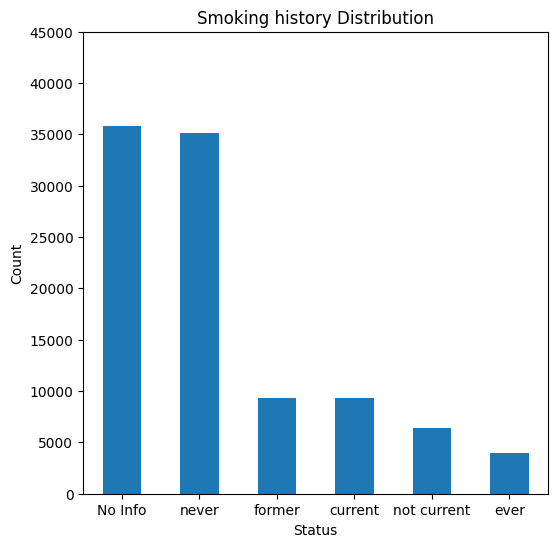

In [97]:
smoking_history_count = data['smoking_history'].value_counts()

# Create a new figure with a fixed size
plt.figure(figsize=(6, 6))

# Plot the gender counts as a bar chart
smoking_history_count.plot(kind='bar')


# Add chart title and axis labels
plt.title('Smoking History Distribution')
plt.xlabel('Status')
plt.ylabel('Count')

# Keep the X-axis labels horizontal
plt.xticks(rotation=0)
plt.yticks(range(0, 50000, 5000))

# Save the figure
plt.savefig('../reports/figures/smoking_history_distribution.png',
            dpi=300,
            bbox_inches='tight')

# Display the chart
plt.show()